# **Lasso Regression From Scratch**

In [69]:
from random import random

import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

In [70]:
class LassoRegression:

    def __init__(self , learning_rate = 0.01 , alpha = 0.1 , epochs = 1000):
        self.learning_rate = learning_rate
        self.alpha = alpha
        self.epochs = epochs

        self.w = None
        self.b = None

        self.loss_history = []

    def fit(self, X_train, y_train):

        n_row, n_features = X_train.shape

        w = np.zeros(n_features)
        b = 0

        for epoch in range(self.epochs):

            # Prediction
            y_hat = X_train @ w + b

            error = y_hat - y_train

            # Gradient
            dw = (
                    (2 / n_row) * (X_train.T @ error)
                    + (self.alpha / n_row) * np.sign(w)
            )

            db = (2 / n_row) * np.sum(error)

            # Loss
            mse = np.mean(error ** 2)

            l1_penalty = (self.alpha / n_row) * np.sign(w)

            loss = mse + l1_penalty

            if epoch % 100 == 0:
                self.loss_history.append(loss)

            # Update
            w -= self.learning_rate * dw
            b -= self.learning_rate * db

            self.w = w
            self.b = b


    def predict(self , X):
        return X @ self.w + self.b


In [71]:
df_raw = load_diabetes(as_frame=True)
df = df_raw.frame

X = df.drop('target' , axis = 1)
y = df['target']

X_train ,  X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=True,
    random_state = 42
)

scaler = StandardScaler(with_mean= True , with_std= True)

print(X_train.shape)
print(X_test.shape)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LassoRegression(
    learning_rate = 0.1,
    alpha = 0.1,
    epochs = 10000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Weights and Bias
print(model.w)
print(model.b)

print(f"MSE : {mean_squared_error(y_test , y_pred)}")
print(f"RMSE : {root_mean_squared_error(y_test , y_pred)}")
print(f"R2 SCORE : {r2_score(y_test , y_pred)}")




(309, 10)
(133, 10)
[  1.35252201 -12.45389414  26.21044752  18.61407193 -43.23674342
  24.23783672   5.72750555  13.95880705  31.56642497   1.98353803]
153.90291262135918
MSE : 2821.739582736719
RMSE : 53.1200487832675
R2 SCORE : 0.4772918278836822


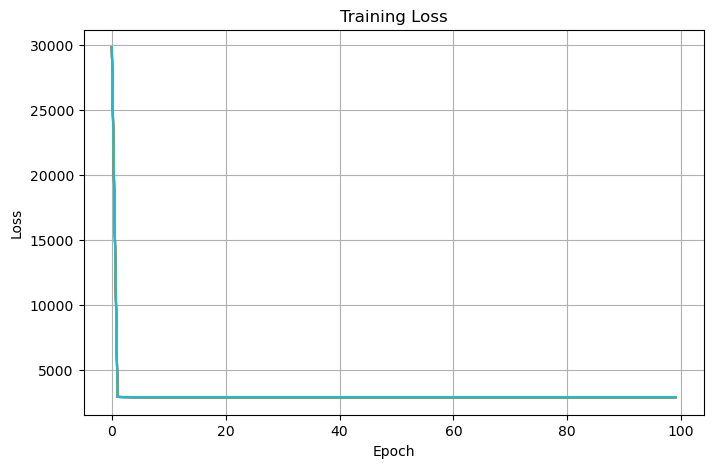

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(len(model.loss_history)), model.loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)
plt.show()

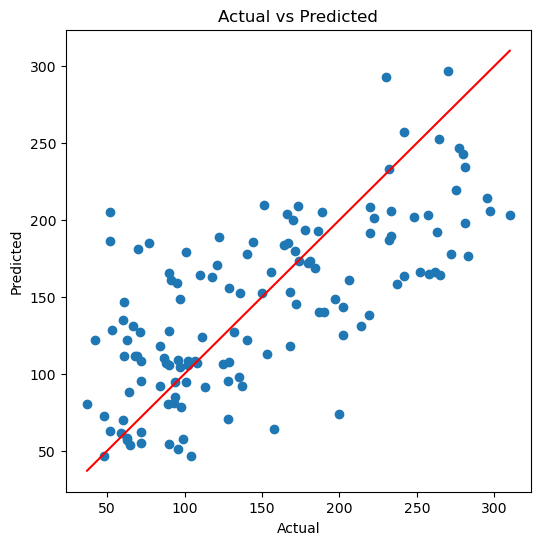

In [73]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()